# Data Diabetes
### Penambangan Data - Informatika Universitas Alma Ata Yogyakarta

- Anggota Kelompok:
1. Alim Cipta Primantara (233200270)
1. Ujang Muamar (233200297)

- Nama Dataset: 
    *"Diabetes*
- Link Sumber Dataset: *https://www.kaggle.com/datasets/therealsaquib/diabates-dataset/data*


In [1]:
# Import library sesuai kebutuhan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# 1. Business Understanding

Pada tahap ini identifikasi permasalahan, tujuan analisis, dan pendekatan data mining yang akan digunakan.

**Tujuan Tahapan:** Menentukan business goal dan data mining goal sebagai dasar proses analisis.

### Jawablah
- Permasalahan Utama: 
    - Tingginya risiko penyakit diabetes yang sering kali terlambat terdeteksi sehingga diperlukan model untuk membantu memprediksi kemungkinan seseorang menderita diabetes berdasarkan data kesehatan. 
- Tujuan bisnis:
    - Membantu proses identifikasi dini terhadap risiko diabetes sehingga dapat menjadi pendukung dalam pengambilan keputusan dan meningkatkan kesadaran terhadap kondisi kesehatan.
- Tujuan Data Mining:
    - Membangun model machine learning yang mampu mengklasifikasikan apakah seseorang berpotensi menderita diabetes atau tidak berdasarkan data kesehatan yang tersedia.
- Pilih salah satu teknik: 
    - Klasifikasi
- Alasan memilih teknik: 
    - Karena target pada dataset berupa dua kelas (Diabetes dan Tidak Diabetes), sehingga permasalahan termasuk klasifikasi. Model akan memprediksi kategori seseorang berdasarkan atribut-atribut kesehatan yang dimiliki.

# 2. Data Understanding

Pada tahap ini lakukan eksplorasi dataset untuk memahami struktur, kualitas, dan karakteristik data.

**Tujuan Tahapan:** Memahami dataset sebelum dilakukan proses persiapan data.

In [2]:
# Muat dataset, jika bukan .csv bisa disesuaikan
import pandas as pd

# Memuat dataset
df = pd.read_csv("diabetes_dataset.csv")

# Menampilkan 5 data pertama
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
# Informasi dataset
df.info()

# Statistik deskriptif
df.describe(include="all")


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
count,100000.00000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000
unique,NaN,3,5,4,5,4,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,Female,White,Highschool,Middle,Employed,Never,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Type 2,NaN
freq,NaN,50216,44997,44891,35152,60175,59813,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59774,NaN
mean,50.12041,NaN,NaN,NaN,NaN,NaN,NaN,2.003670,118.911640,5.994787,...,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,NaN,0.599980
std,15.60460,NaN,NaN,NaN,NaN,NaN,NaN,1.417779,84.409662,1.780954,...,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,NaN,0.489904
min,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,NaN,0.000000
25%,39.00000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,57.000000,4.800000,...,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,NaN,0.000000
50%,50.00000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,100.000000,6.000000,...,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,NaN,1.000000
75%,61.00000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,160.000000,7.200000,...,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,NaN,1.000000


In [4]:
# Mengecek missing value
print(df.isnull().sum())

# Mengecek data duplikat
print("Jumlah data duplikat :", df.duplicated().sum())

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


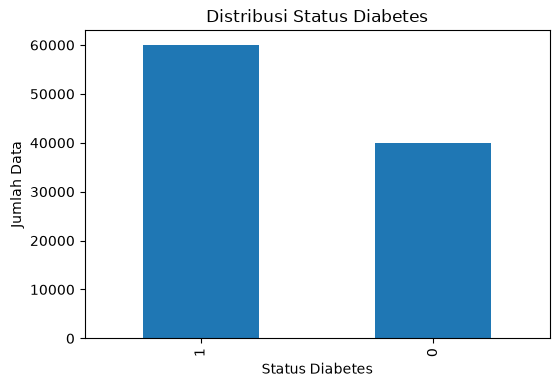

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['diagnosed_diabetes'].value_counts().plot(kind='bar')

plt.title('Distribusi Status Diabetes')
plt.xlabel('Status Diabetes')
plt.ylabel('Jumlah Data')

plt.show()

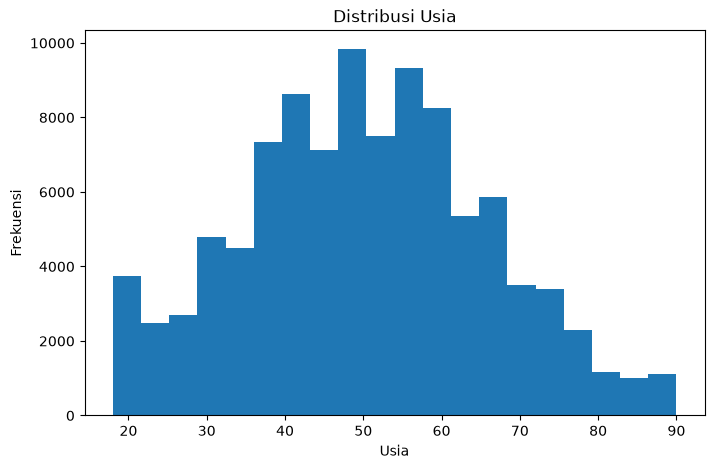

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=20)

plt.title('Distribusi Usia')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')

plt.show()

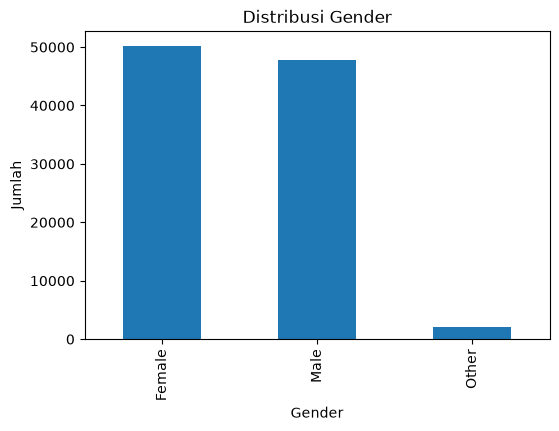

In [7]:
plt.figure(figsize=(6,4))

df['gender'].value_counts().plot(kind='bar')

plt.title('Distribusi Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')

plt.show()

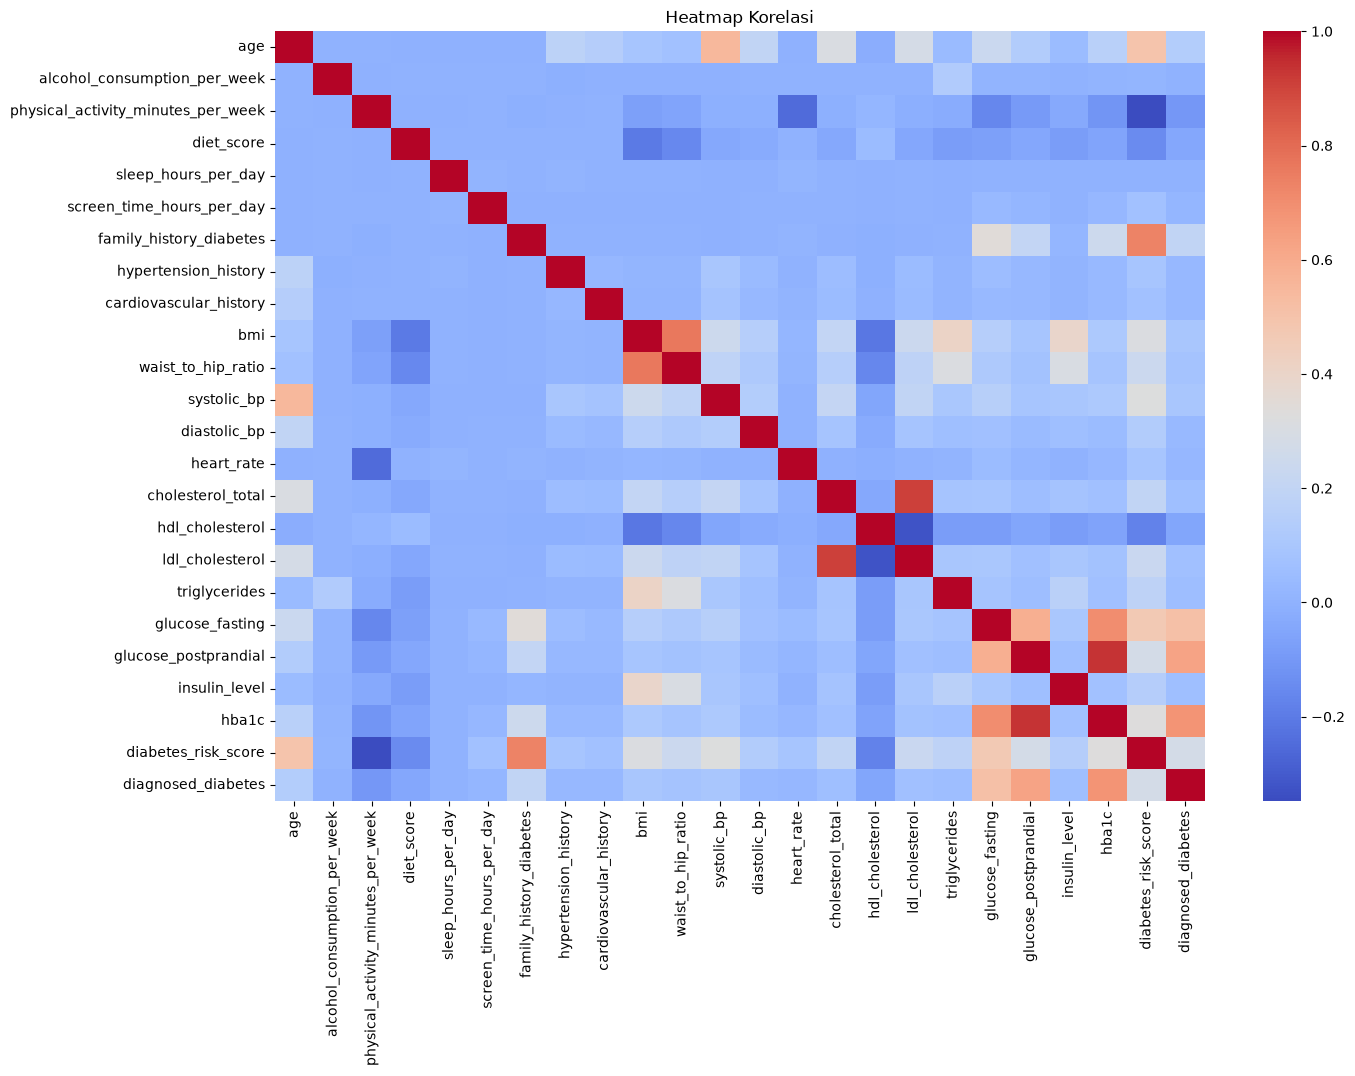

In [8]:
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap='coolwarm')

plt.title("Heatmap Korelasi")

plt.show()

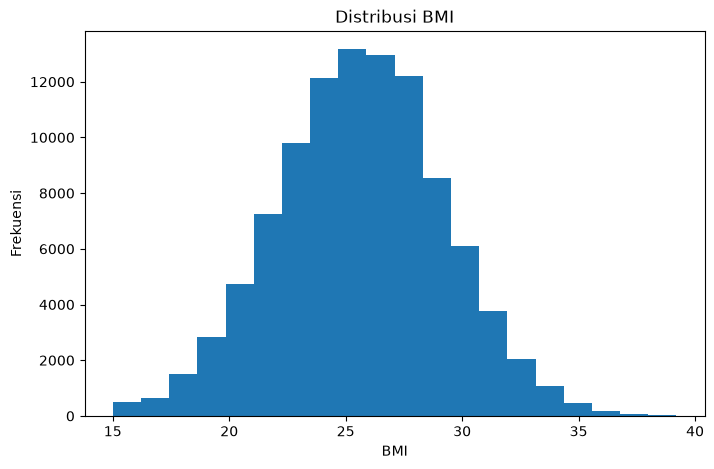

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['bmi'], bins=20)

plt.title("Distribusi BMI")
plt.xlabel("BMI")
plt.ylabel("Frekuensi")

plt.show()

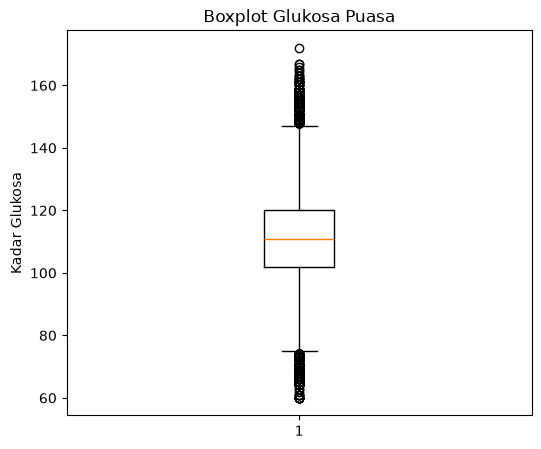

In [10]:
plt.figure(figsize=(6,5))

plt.boxplot(df['glucose_fasting'])

plt.title("Boxplot Glukosa Puasa")

plt.ylabel("Kadar Glukosa")

plt.show()

### 💡 Insight

Hasil pengecekan menggunakan `df.info()` menunjukkan bahwa seluruh kolom memiliki **100.000 non-null values**, sehingga dapat disimpulkan bahwa dataset **tidak memiliki missing value**.

Selain itu, hasil pengecekan data duplikat menunjukkan bahwa **tidak terdapat data duplikat** pada dataset. Dengan demikian, dataset memiliki kualitas yang baik dan siap memasuki tahap **Data Preparation**, yaitu proses pengolahan data sebelum dilakukan pemodelan machine learning.

# 3. Data Preparation

**Tujuan Tahapan:** tujuan kita adalah menyiapkan data agar dapat diproses oleh algoritma machine learning.

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [12]:
print(df.columns)

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='str')


In [13]:
# Memilih fitur-fitur penting
X = df[[
    'age',
    'bmi',
    'glucose_fasting',
    'hba1c',
    'family_history_diabetes',
    'hypertension_history'
]]

# Target
y = df['diagnosed_diabetes']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Latih :", X_train.shape)
print("Data Uji   :", X_test.shape)

Data Latih : (80000, 6)
Data Uji   : (20000, 6)


### 💡 Insight

Pada tahap **Data Preparation**, dilakukan proses penyiapan data sebelum memasuki tahap pemodelan. Berdasarkan hasil **Data Understanding**, dataset tidak memiliki missing value maupun data duplikat sehingga tidak diperlukan proses pembersihan data.

Selanjutnya dilakukan **encoding** pada atribut yang bertipe kategorikal, seperti *gender*, *ethnicity*, *education_level*, *income_level*, *employment_status*, dan *smoking_status*. Proses ini bertujuan mengubah data berbentuk teks menjadi data numerik agar dapat diproses oleh algoritma machine learning.

Setelah proses encoding selesai, dataset dipisahkan menjadi **fitur (X)** dan **target (y)**. Kemudian data dibagi menjadi **data latih (80%)** dan **data uji (20%)** menggunakan metode *train-test split*. Pembagian ini bertujuan agar model dapat dilatih menggunakan data latih dan dievaluasi menggunakan data uji sehingga performanya dapat diukur secara objektif.

# 4. Modeling

**Tujuan Tahapan:** Membangun model machine learning menggunakan algoritma Random Forest Classifier untuk memprediksi status diabetes berdasarkan fitur-fitur pada dataset. 

Di tahap ini kami menggunakan algoritma **Random Forest Classifier**

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
print(y_pred[:10])

[0 1 0 0 0 0 1 1 1 1]


### 💡 Insight

Pada tahap Modeling digunakan algoritma **Random Forest Classifier** untuk membangun model prediksi diabetes. Random Forest dipilih karena mampu menangani dataset dengan jumlah data yang besar, memiliki performa yang baik pada kasus klasifikasi, serta lebih tahan terhadap overfitting dibandingkan Decision Tree tunggal.

Model kemudian dilatih menggunakan data latih (*training data*) yang telah dipersiapkan pada tahap sebelumnya. Setelah proses pelatihan selesai, model digunakan untuk melakukan prediksi terhadap data uji (*testing data*). Hasil prediksi tersebut akan dievaluasi pada tahap berikutnya untuk mengetahui tingkat akurasi dan performa model.

# 5. Evaluation

Evaluasi model menggunakan metrik yang sesuai.

**Tujuan Tahapan:** Tahap **Evaluation** bertujuan untuk mengukur dan mengevaluasi performa model Random Forest yang telah dibangun dalam memprediksi status diabetes. Evaluasi dilakukan menggunakan beberapa metrik, yaitu **Accuracy Score**, **Classification Report**, dan **Confusion Matrix**. Hasil evaluasi digunakan untuk mengetahui seberapa baik model dalam melakukan klasifikasi serta memastikan bahwa model memiliki performa yang layak sebelum digunakan pada tahap deployment.

Akurasi Model: 91.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      8077
           1       0.99      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.91      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



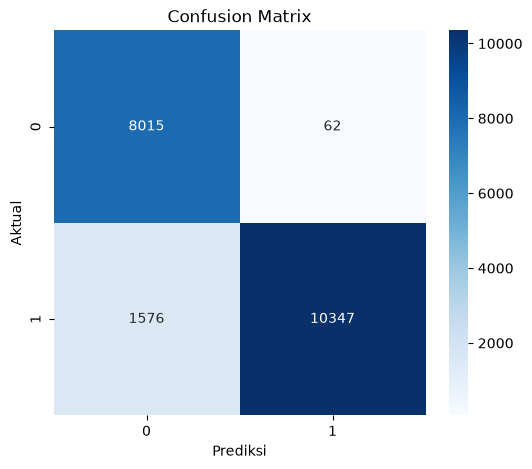

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy:.2%}")

# Menampilkan Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

### 💡 Insight

Berdasarkan hasil evaluasi, model Random Forest memperoleh **akurasi sebesar 91,81%**, yang menunjukkan bahwa model mampu mengklasifikasikan status diabetes dengan tingkat ketepatan yang baik.

Hasil **Classification Report** menunjukkan bahwa model memiliki nilai **precision**, **recall**, dan **F1-score** yang tinggi pada kedua kelas. Hal ini mengindikasikan bahwa model mampu membedakan data pasien yang terdiagnosis diabetes maupun yang tidak terdiagnosis dengan performa yang cukup seimbang.

Selain itu, **Confusion Matrix** memperlihatkan bahwa sebagian besar data berhasil diprediksi dengan benar, meskipun masih terdapat sejumlah kecil kesalahan klasifikasi. Secara keseluruhan, model Random Forest dapat digunakan sebagai model prediksi diabetes karena memberikan performa yang baik pada dataset yang digunakan.

# 6. Deployment

Implementasikan model menggunakan Streamlit.

**Tujuan Tahapan:** Mengimplementasikan model Random Forest ke dalam aplikasi berbasis Streamlit sehingga pengguna dapat memasukkan data dan memperoleh hasil prediksi status diabetes secara mudah.

Langkah:
- simpan model dalam format (.pkl/.joblib)
- Siapkan file baru app.py untuk deploy streamlit *[boleh berbantuan AI]*
- Jalankan aplikasi streamlit app.py
- Sertakan screenshot hasil 

In [18]:
import joblib

# Menyimpan model
joblib.dump(model, "model_diabetes.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [19]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

# 7. Kesimpulan

Berdasarkan hasil proyek yang telah dilakukan menggunakan metodologi **CRISP-DM**, dapat disimpulkan beberapa hal sebagai berikut.

1. Permasalahan
Permasalahan yang diangkat dalam proyek ini adalah bagaimana membangun model machine learning yang mampu memprediksi status diabetes berdasarkan data kesehatan pasien. Prediksi dini terhadap diabetes diharapkan dapat membantu dalam proses deteksi awal sehingga risiko komplikasi penyakit dapat diminimalkan.

2. Teknik dan Algoritma
Pada penelitian ini digunakan metodologi **CRISP-DM** yang terdiri dari enam tahapan, yaitu Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment. Proses klasifikasi dilakukan menggunakan algoritma **Random Forest Classifier**. Untuk menyederhanakan model sekaligus mempermudah proses deployment, digunakan enam fitur utama, yaitu **age**, **bmi**, **glucose_fasting**, **hba1c**, **family_history_diabetes**, dan **hypertension_history**.

3. Hasil Evaluasi
Berdasarkan hasil evaluasi menggunakan **Accuracy Score**, **Classification Report**, dan **Confusion Matrix**, model Random Forest memperoleh nilai akurasi sebesar **91,81%**. Nilai tersebut menunjukkan bahwa model mampu melakukan klasifikasi status diabetes dengan performa yang baik. Selain itu, nilai precision, recall, dan F1-score juga menunjukkan hasil yang cukup tinggi sehingga model dinilai mampu membedakan data pasien yang terdiagnosis maupun tidak terdiagnosis diabetes dengan baik.

4. Apakah Tujuan Tercapai
Tujuan proyek berhasil dicapai, yaitu membangun model machine learning yang mampu memprediksi status diabetes dengan tingkat akurasi yang baik serta mengimplementasikan model tersebut ke dalam aplikasi berbasis **Streamlit** sehingga dapat digunakan untuk melakukan prediksi terhadap data baru secara lebih mudah dan interaktif.

5. Saran Pengembangan
Pengembangan selanjutnya dapat dilakukan dengan menggunakan dataset yang lebih beragam dan lebih besar agar model memiliki kemampuan generalisasi yang lebih baik. Selain itu, performa model dapat dibandingkan dengan algoritma klasifikasi lainnya seperti **Decision Tree**, **Support Vector Machine (SVM)**, atau **XGBoost**. Aplikasi Streamlit juga dapat dikembangkan dengan menambahkan visualisasi hasil prediksi, riwayat prediksi, maupun fitur penyimpanan data pengguna agar lebih bermanfaat dalam implementasi nyata.
